# Project Title

Analysis of Traffic Patterns and Congestion in Bangalore Using Python

# Domain
Retail / E-commerce

(Traffic analysis supports logistics, delivery operations, and urban commerce. Hence it fits under Retail / E-commerce.)

# Objective

* To identify meaningful traffic patterns, trends, and congestion insights in Bangalore using exploratory data analysis (EDA)

* To clean, transform, and preprocess traffic data for effective analysis

* To create meaningful visualizations that clearly explain traffic behavior

* To provide actionable insights and recommendations to improve traffic management

# Outcome

The project uncovers peak traffic hours, congestion-prone areas, and factors affecting traffic flow in Bangalore. The analysis provides a clear understanding of traffic patterns and supports data-driven decision-making for urban mobility and planning..

#Dataset Information

Source: Kaggle

Dataset Name: Bangalore City Traffic Dataset

Kaggle Link: https://www.kaggle.com/datasets/preethamgouda/banglore-city-traffic-dataset

Year / Timeline: Data collected during 2024 – 2025

Dataset Description:

The dataset contains traffic information from various locations in Bangalore. It includes traffic volume, average speed, congestion level, weather conditions, and location details. The dataset is suitable for analyzing traffic patterns and congestion trends.

Features Used in This Project

🔹 Categorical Columns (4)

🔹 Numerical Columns (11)

#Type of Analysis

Descriptive Analysis: Summarizing traffic data using statistics

Diagnostic Analysis: Identifying reasons behind congestion

Prescriptive Analysis: Recommendations to reduce congestion

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection

Problem Definition: Traffic congestion is a major issue in Bangalore. Understanding traffic patterns can help improve traffic flow and reduce congestion.

Expected Outcome: To identify peak hours, high-congestion areas, and contributing factors such as weather and location.

Dataset Selection: The Bangalore City Traffic Dataset from Kaggle was chosen due to its real-world relevance and availability of both numerical and categorical features.


Import Libraries, Load Dataset, Initial EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
files.upload()

Saving Banglore_traffic_Dataset.csv to Banglore_traffic_Dataset.csv


{'Banglore_traffic_Dataset.csv': b'Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity\n2022-01-01,Indiranagar,100 Feet Road,50590,50.23029856408026,1.5,100.0,100.0,0,151.18,70.63233020424546,84.04460046972835,85.40362888980228,111,Clear,No\n2022-01-01,Indiranagar,CMH Road,30825,29.377124707590273,1.5,100.0,100.0,1,111.65,41.92489889519251,91.40703845572054,59.98368910791799,100,Clear,No\n2022-01-01,Whitefield,Marathahalli Bridge,7399,54.47439821046639,1.0390688456025536,28.34799386357647,36.39652493739601,0,64.798,44.66238370778891,61.375540844608736,95.4660201039391,189,Clear,No\n2022-01-01,Koramangala,Sony World Junction,60874,43.817610389486106,1.5,100.0,100.0,1,171.748,32.7731231534285,75.54709158757927,63.567451588694794,111

In [ ]:
df = pd.read_csv("Banglore_traffic_Dataset.csv")
df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   object 
 1   Area Name                           8936 non-null   object 
 2   Road/Intersection Name              8936 non-null   object 
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 no

In [ ]:
# Statistical summary
df.describe()

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
count,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000
mean,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348
std,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573
min,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000
25%,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000
50%,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000
75%,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000
max,72039.000000,89.790843,1.500000,100.000000,100.000000,10.000000,194.078000,79.979744,99.993652,99.995049,243.000000


In [ ]:
# Dataset shape
df.shape


(8936, 16)

In [ ]:
# Check missing values
df.isnull().sum()


,0
Date,0
Area Name,0
Road/Intersection Name,0
Traffic Volume,0
Average Speed,0
Travel Time Index,0
Congestion Level,0
Road Capacity Utilization,0
Incident Reports,0
Environmental Impact,0


In [ ]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

## Stage 2 – Data Cleaning and Pre-processing

Handle missing values (impute or drop)

Handle duplicates

Convert data types if needed

 Handle Missing Values

In [ ]:
# Drop rows with missing values
df=df.dropna()

#Impute missing values

check datatypes

In [ ]:
df.dtypes

,0
Date,object
Area Name,object
Road/Intersection Name,object
Traffic Volume,int64
Average Speed,float64
Travel Time Index,float64
Congestion Level,float64
Road Capacity Utilization,float64
Incident Reports,int64
Environmental Impact,float64


In [ ]:
#Numerical columns → fill with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


In [ ]:
# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Check & Handle Duplicates

In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

Convert Data Types

In [ ]:
#check datatypes
df.dtypes

,0
Date,object
Area Name,object
Road/Intersection Name,object
Traffic Volume,int64
Average Speed,float64
Travel Time Index,float64
Congestion Level,float64
Road Capacity Utilization,float64
Incident Reports,int64
Environmental Impact,float64


In [ ]:
# Convert date column to datetime (if present)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [ ]:
df.head(1)

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.5,100.0,100.0,0,151.18,70.63233,84.0446,85.403629,111,Clear,No


In [ ]:
# Convert numeric columns stored as text
df['Traffic Volume'] = pd.to_numeric(df['Traffic Volume'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Date                                8936 non-null   datetime64[ns]
 1   Area Name                           8936 non-null   object        
 2   Road/Intersection Name              8936 non-null   object        
 3   Traffic Volume                      8936 non-null   int64         
 4   Average Speed                       8936 non-null   float64       
 5   Travel Time Index                   8936 non-null   float64       
 6   Congestion Level                    8936 non-null   float64       
 7   Road Capacity Utilization           8936 non-null   float64       
 8   Incident Reports                    8936 non-null   int64         
 9   Environmental Impact                8936 non-null   float64       
 10  Public Transport Usage  

## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

--- Focus on business story not just charts ---

Each chart must be in seperate cells.

# Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

**1. Distribution of Traffic Volume (Histogram)**

In [ ]:
df.head(1)

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.5,100.0,100.0,0,151.18,70.63233,84.0446,85.403629,111,Clear,No


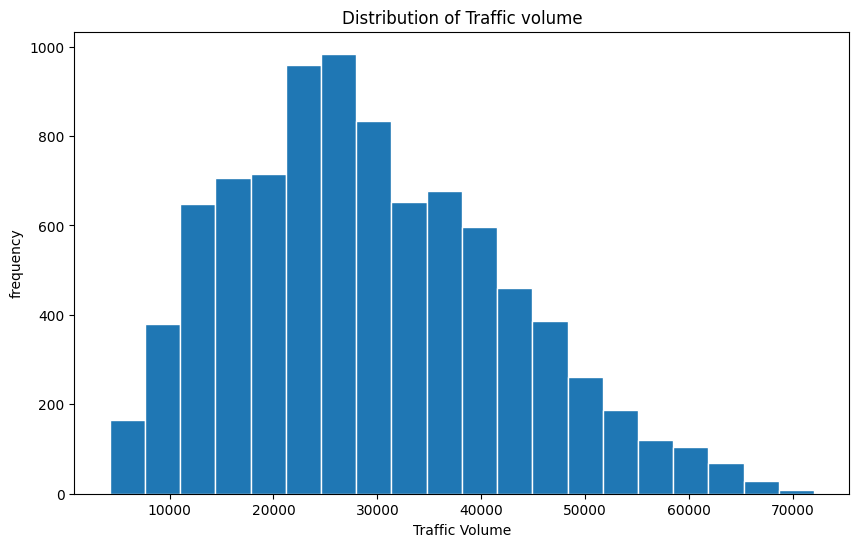

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df["Traffic Volume"],bins=20,color="#1f77b4", edgecolor="white")
plt.xlabel("Traffic Volume")
plt.ylabel("frequency")
plt.title("Distribution of Traffic volume")
plt.show()


**Interpretation of Histogram chart** :

Explain the Chart:

  This is a histogram that shows the distribution of traffic volume values in the dataset. It groups traffic volume into 20 ranges (bins) and displays how frequently each range occurs.

What is it saying?

The chart tells us how traffic volume is spread across different levels. It shows whether most roads experience low, medium, or high traffic and helps identify common traffic patterns and peak traffic ranges.

What features used?

Traffic Volume (Numerical feature)
From this, what are we showing us? We are showing the frequency distribution of traffic volume, which helps us understand:

  * Normal traffic levels

  * Peak congestion periods

  * Whether traffic volume is evenly distributed or skewed toward high or low values

Business Insight:

  * This analysis helps traffic authorities identify high-traffic conditions, plan better traffic management, and optimize road infrastructure usage.

**2. Congestion Level Distribution (Box plot)**

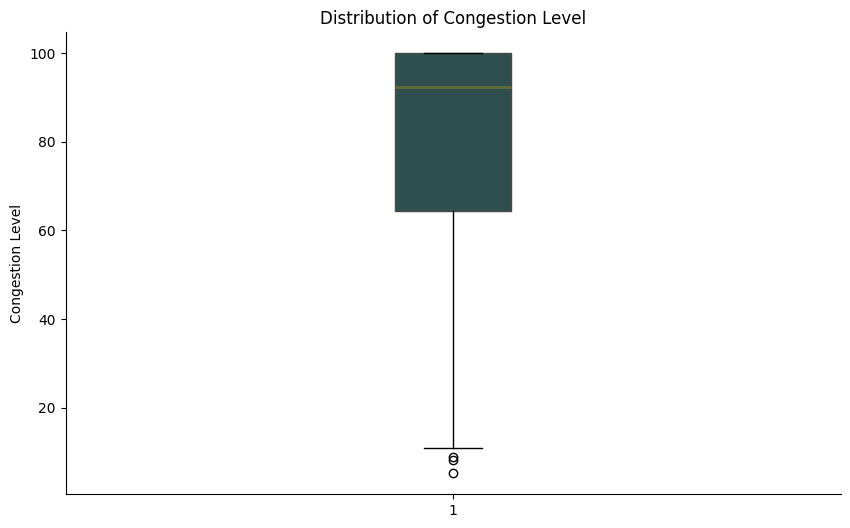

In [ ]:
plt.figure(figsize=(10, 6))
box = plt.boxplot(df['Congestion Level'], patch_artist=True)

# Set the 'mild' colors
# Box color (Mild Sage)
box['boxes'][0].set_facecolor('#2F4F4F')
box['boxes'][0].set_edgecolor('#4A4A4A')

# Median line color (Soft Coral for visibility)
box['medians'][0].set_color('#606C38')
box['medians'][0].set_linewidth(2)
plt.ylabel('Congestion Level')
plt.title('Distribution of Congestion Level')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()


**Interpretation of Box plot chart :**

Explain the Chart:

This is a boxplot that shows the distribution of the Congestion Level variable. It summarizes the data using the minimum, first quartile (Q1), median, third quartile (Q3), and maximum values, along with any outliers.

What is it saying?

The chart explains how congestion levels are spread across the dataset. It highlights the central congestion level, the variability, and whether there are extreme congestion values (outliers).

What features used?

  * Congestion Level (Numerical feature)
From this, what are we showing us? We are showing:

  * The median congestion level (typical congestion)

  * The range and spread of congestion across roads

  * The presence of outliers, which represent unusually high or low congestion situations.

Business Insight :
  * This visualization helps traffic planners identify abnormal congestion patterns, evaluate traffic stability, and take targeted actions for roads experiencing extreme congestion.

 **3. Traffic Records by Weather Conditions (Count plot)**

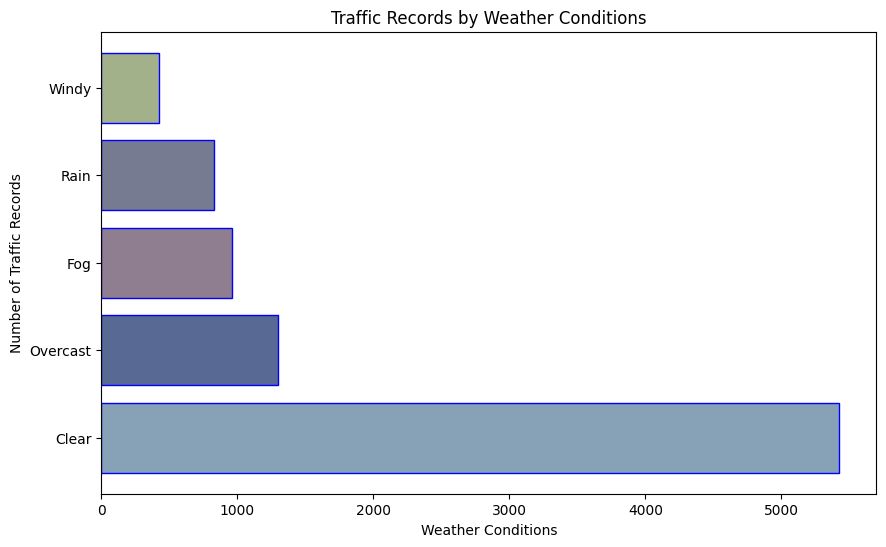

In [ ]:
# Count plot for Weather Conditions
weather_counts = df['Weather Conditions'].value_counts()
colors = ["#87A2B6", "#586994","#8F7E8F","#767B91","#A3B18A"]
plt.figure(figsize=(10, 6))
plt.barh(weather_counts.index, weather_counts.values,color=colors,edgecolor="blue")
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Traffic Records')
plt.title('Traffic Records by Weather Conditions')
plt.show()

**Interpretation of Count plot chart :**

Explain the Chart:

This is a bar chart that displays the count of traffic records for each Weather Condition category. Each bar represents how many traffic observations occurred under a specific weather condition.

What is it saying?

The chart shows which weather conditions occur most frequently in the traffic dataset.
It helps us understand under what weather conditions traffic data is most commonly recorded, such as clear, rainy, or cloudy conditions.

What features used?

  * Weather Conditions (Categorical feature)

What are showing:

  * The frequency of traffic records under different weather conditions

  * Which weather condition has the highest and lowest occurrence

  * How weather patterns are distributed across traffic observations

Business Insight

  * This analysis helps traffic authorities assess how often traffic operates under various weather conditions and supports planning for weather-specific traffic management strategies, especially during adverse conditions like rain or fog.

# Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

**1. Scatter Plot (Traffic Volume vs Average Speed)**

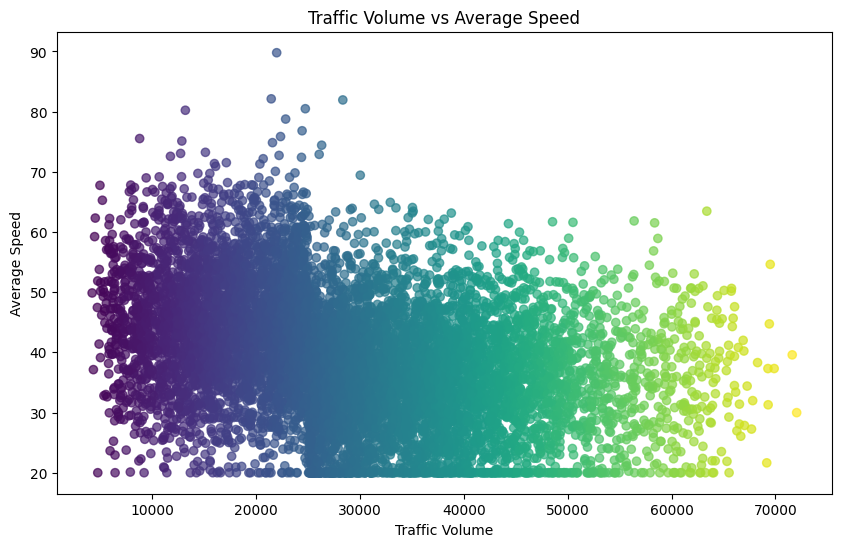

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Traffic Volume'], df['Average Speed'],c=df['Traffic Volume'], cmap='viridis', alpha=0.7)
plt.xlabel('Traffic Volume')
plt.ylabel('Average Speed')
plt.title('Traffic Volume vs Average Speed')
plt.show()

**Interpretation of Scatter plot chart :**

What is the chart saying?

The scatter plot shows an inverse relationship between traffic volume and average speed. As traffic volume increases, average speed generally decreases.

Variables used:

  * Traffic Volume (Numerical)

  * Average Speed (Numerical)

What it is showing?

 how road congestion impacts vehicle speed.

Business Insight:

High traffic volume directly reduces travel speed, leading to delays, fuel wastage, and commuter dissatisfaction.
This insight helps traffic authorities:

  * Identify overloaded roads

  * Improve traffic signal timing

  * Encourage public transport usage during peak hours

2.**Average Traffic Volume by Area(Bar Plot)**

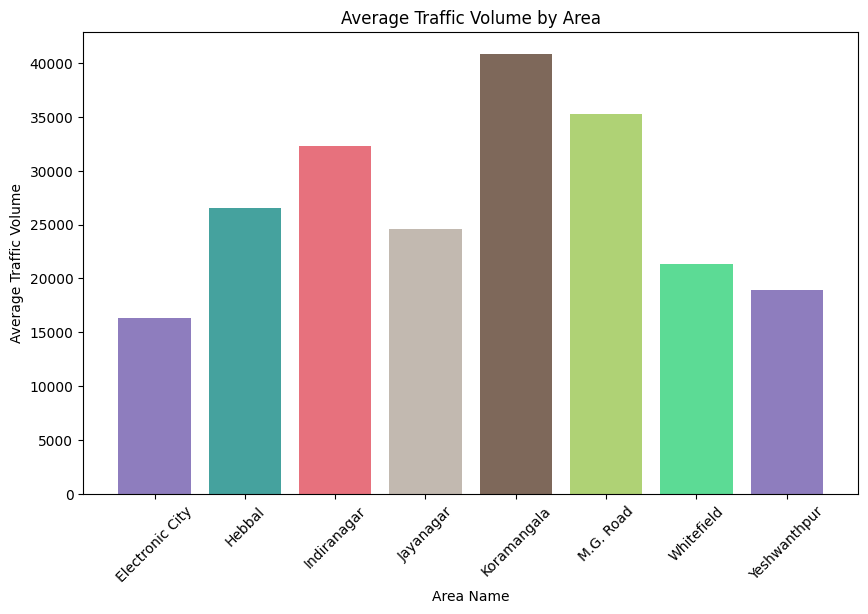

In [ ]:
area_traffic = df.groupby('Area Name')['Traffic Volume'].mean()
plt.figure(figsize=(10, 6))
colors= ["#8E7DBE", "#45A29E", "#E7717D", "#C2B9B0", "#7E685A", "#AFD275", "#5CDB95"]
plt.bar(area_traffic.index, area_traffic.values,color=colors[:len(area_traffic)])
plt.xlabel('Area Name')
plt.ylabel('Average Traffic Volume')
plt.title('Average Traffic Volume by Area')
plt.xticks(rotation=45)
plt.show()

**Interpretation of Bar plot :**

What is the chart saying?

The bar plot compares average traffic volume across different areas.

Variables used:

  * Area Name (Categorical)

  * Traffic Volume (Numerical)

What it is showing?

It's showing which areas experience higher traffic pressure.

Business Insight:

Areas with higher average traffic volume indicate high demand zones.
This helps:

  * Urban planners prioritize road expansion

  * Police deploy traffic control personnel

  * Authorities improve public transport connectivity in busy areas

**3.Congestion Level vs Travel Time Index (Scatter Plot)**

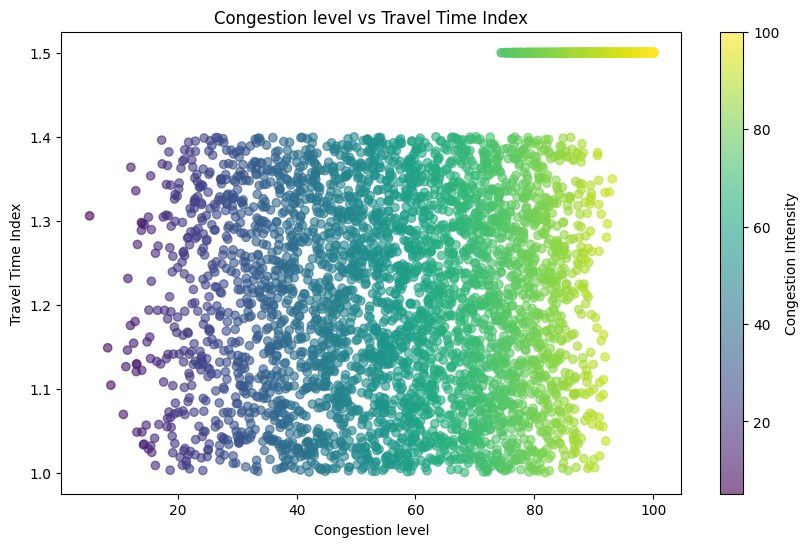

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Congestion Level'],df['Travel Time Index'],c=df['Congestion Level'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Congestion Intensity')
plt.xlabel('Congestion level')
plt.ylabel('Travel Time Index')
plt.title('Congestion level vs Travel Time Index')
plt.show()

**Interpretation of Scatter plot:**

What is the chart saying?

As congestion level increases, the travel time index also increases, indicating longer travel times compared to free-flow conditions.

Variables used:

  * Congestion Level (Numerical)

  * Travel Time Index (Numerical)

What it is showing?

It's showing the direct impact of congestion on commuter travel time.

Business Insight:

Higher congestion leads to inefficiency and productivity loss.
This supports decisions like:

  * Implementing peak-hour restrictions

  * Promoting remote work policies

  * Designing alternate traffic routes

4. **Relationship Between Traffic Metrics(Correlation Heatmap)**

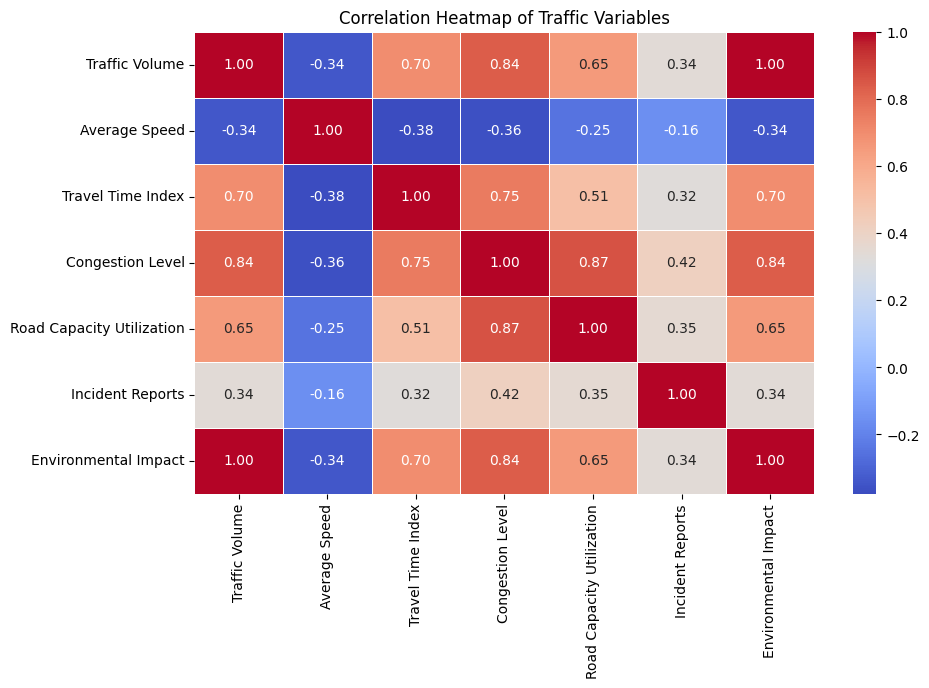

In [ ]:
# Select numerical columns
num_cols = [
    'Traffic Volume', 'Average Speed', 'Travel Time Index',
    'Congestion Level', 'Road Capacity Utilization',
    'Incident Reports', 'Environmental Impact'
]

# Correlation matrix
corr = df[num_cols].corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap of Traffic Variables')
plt.show()

**Interpretation of Correlation Heatmap:**

What is the chart saying?

The heatmap shows the strength and direction of relationships between key traffic variables. Darker colors indicate stronger correlations, while lighter colors indicate weaker relationships.

Variables used:

  * Traffic Volume

  * Average Speed

  * Travel Time Index

  * Congestion Level

  * Road Capacity Utilization

  * Incident Reports

  * Environmental Impact

What it is showing?

  * Traffic Volume has a positive correlation with Congestion Level and Road Capacity Utilization

  * Traffic Volume has a negative correlation with Average Speed

  * Congestion Level is positively correlated with Travel Time Index

  * Higher congestion is associated with increased Environmental Impact

Business Insight:

This heatmap helps decision-makers understand which factors move together:

  * When traffic volume rises, congestion increases and speed drops → longer commute times

  * High congestion leads to higher emissions → environmental concerns

  * Strong correlations allow authorities to predict congestion early using traffic volume data



# Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

**1. Pairplot of Traffic Volume, Average Speed, Congestion Level**

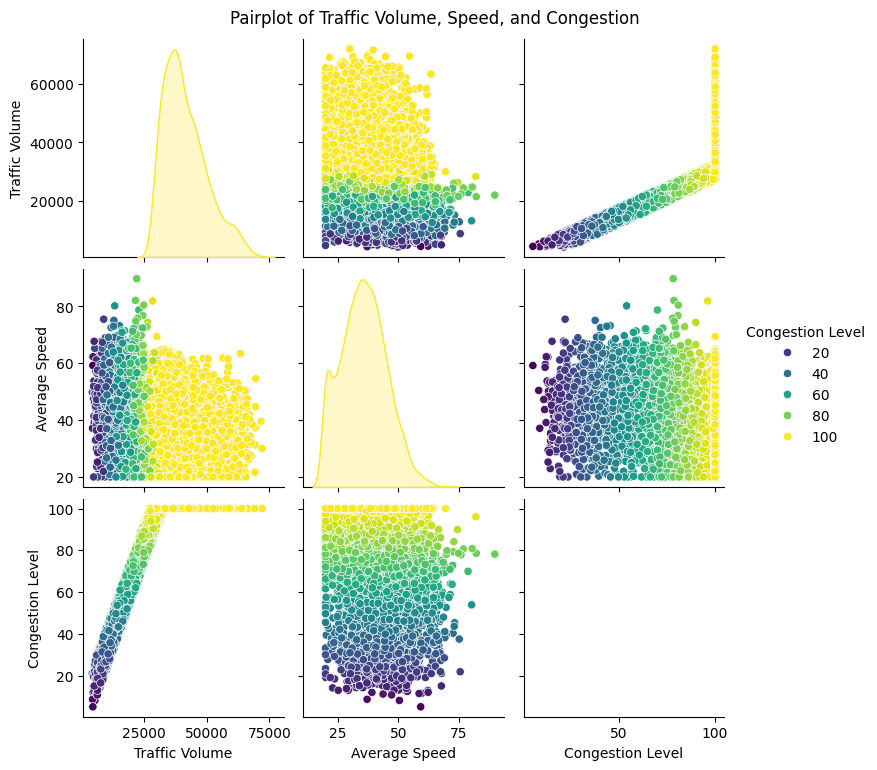

In [ ]:
sns.pairplot(
    df,
    vars=['Traffic Volume', 'Average Speed', 'Congestion Level'],
    hue='Congestion Level',
    palette='viridis',
    diag_kind='kde'
)
plt.suptitle('Pairplot of Traffic Volume, Speed, and Congestion', y=1.02)
plt.show()

**Interpretation of Pair Plot:**

What is the chart saying?

The pairplot shows pairwise relationships among traffic volume, average speed, and congestion level, along with their individual distributions.

Variables used:

  * Traffic Volume

  * Average Speed

  * Congestion Level

What it is showing?

  * Higher traffic volume is associated with lower speed

  * Higher traffic volume leads to higher congestion

  * Speed decreases as congestion increases

Business Insight:

This confirms a cause–effect chain:

  * High traffic volume → High congestion → Low speed

**2.Grouped Bar Plot of Average Traffic Volume by Area & Weather Conditions**

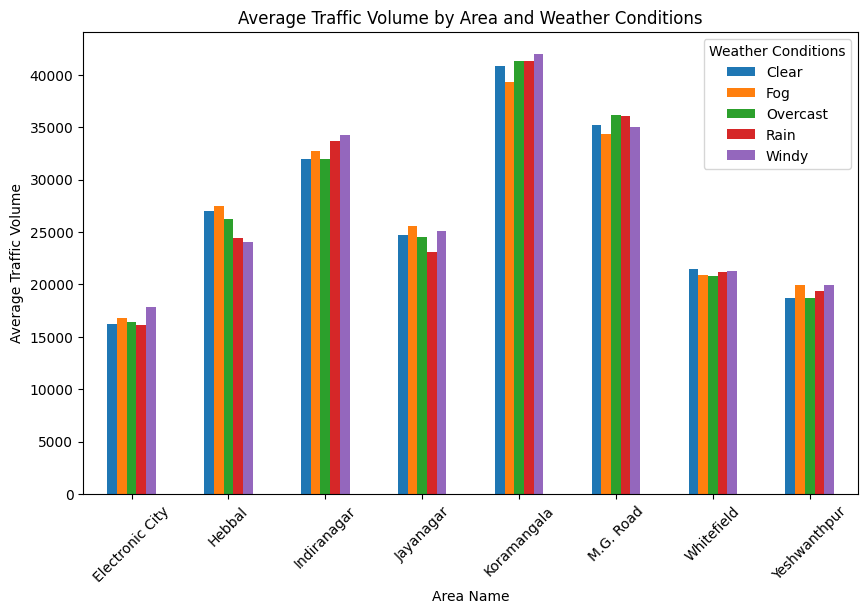

In [ ]:
grouped_data = df.groupby(['Area Name', 'Weather Conditions'])['Traffic Volume'].mean().unstack()

grouped_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Area Name')
plt.ylabel('Average Traffic Volume')
plt.title('Average Traffic Volume by Area and Weather Conditions')
plt.xticks(rotation=45)
plt.show()

**Interpretation of Grouped Bar Plot:**

What is the chart saying?

The chart compares traffic volume across different areas under different weather conditions.

Variables used:

  * Area Name (Categorical)

  * Weather Conditions (Categorical)

  * Traffic Volume (Numerical)

What it is showing?

  * Some areas experience consistently high traffic regardless of weather

  * Weather impacts traffic volume differently across areas

Business Insight:

This helps authorities:

  * Deploy weather-based traffic control plans

  * Prepare extra traffic management during rain in sensitive zones

  * Design area-specific traffic strategies instead of one-size-fits-all

**3. Pivot Table Analysis of Congestion Level by Area and Roadwork Activity**

In [ ]:
pivot_congestion = pd.pivot_table(
    df,
    values='Congestion Level',
    index='Area Name',
    columns='Roadwork and Construction Activity',
    aggfunc='mean'
)

pivot_congestion

Roadwork and Construction Activity,No,Yes
Area Name,,
Electronic City,54.815500,50.983416
Hebbal,79.998762,80.777077
Indiranagar,87.638530,87.676806
Jayanagar,77.000373,76.978716
Koramangala,94.193122,92.253757
M.G. Road,90.503843,91.177310
Whitefield,69.131109,68.263469
Yeshwanthpur,62.848263,57.181908


**Interpretation of Pivot table:**

What is the chart saying?

The pivot table compares average congestion levels across areas based on roadwork presence.

Variables used:

  * Area Name

  * Roadwork and Construction Activity

  * Congestion Level

What it is showing?

  * Areas with roadwork generally show higher congestion

  * Impact of roadwork varies by location

Business Insight:

This insight helps:

  * Schedule roadwork during low-traffic periods

  * Inform the public in advance

  * Reduce congestion caused by poor construction planning

**4. Bubble Plot of Traffic Volume vs Speed vs Congestion Level**

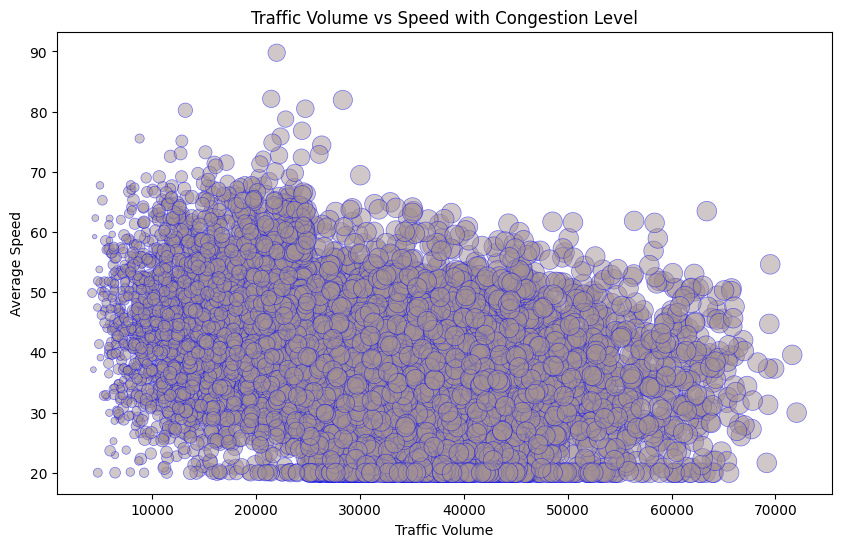

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Traffic Volume'],df['Average Speed'],
    s=df['Congestion Level'] * 2,
    color='#A39193',
    alpha=0.5,
    edgecolor='blue',
    linewidth=0.5
)
plt.xlabel('Traffic Volume')
plt.ylabel('Average Speed')
plt.title('Traffic Volume vs Speed with Congestion Level')
plt.show()

**Interpretation of Bubble Plot:**

What is the chart saying?

The bubble size represents congestion level, adding a third dimension to the relationship between volume and speed.

Variables used:

  * Traffic Volume

  * Average Speed

  * Congestion Level

What it is showing?

  * Large bubbles appear where traffic volume is high and speed is low

  * Congestion intensifies traffic inefficiency

Business Insight:

This visualization clearly highlights critical congestion zones, enabling:

  * Faster identification of problem roads

  * Data-backed traffic signal optimization

  * Smarter urban mobility planning

## Stage 4 – Documentation, Insights and Presentation

Show a dashboard aligning all the charts in powerbi

Summarize findings in plain English (what do the patterns mean)

Highlight 3–5 key insights (trends, anomalies, correlations)

Provide recommendations for business or decision-making

Explain the FINAL STORY WITH THE DASHBOARD

Create a PDF pasting your DASHBOARD, explaining all the above mentioned concepts and submit it


In [ ]:
# your stage 4 pdf Link

'''
step1 --> Create a docs that should have all the above mentioned
step2 --> Save it as "Stage4_doc"
Step3 --> Download it as PDF
step4 --> Upload the pdf in your drive
step5 --> Right click on your pdf in drive
step6 --> click share and change access into anyone with the link (Viewer)
step7 --> click copy link and paste it here...
You are done.
'''

# Future Enhancement

Use a larger or more recent dataset for deeper insights

Automate parts of the analysis with scripts or dashboards

Add advanced visualizations and interactive dashboards in Power BI or Tableau

Extend the analysis to predictive modeling for forecasting if needed

# Conclusion

From the analysis, we identified meaningful relationships and patterns in the dataset. The visualizations and insights highlight the main factors influencing the outcomes and provide a strong foundation for business decisions.